# Peru SISepuede Article 6 – Full Tutorial Notebook

This notebook is designed to help you and other users generate simulations to support Article 6 analysis:

- Understand the overall workflow used to construct, transform, and run SISepuede inputs for Peru
- See how directory paths, data files, and model attributes are configured
- Follow how the Peru input dataframe is built from pipeline output and example data
- Learn how the Transformers / Transformations / Strategies machinery is initialized
- See where helper CSVs (inputs and attributes) are written for cloud/batch use
- Understand how the high-level `SISEPUEDEModels` runner is constructed and used
- Inspect additional exploratory, validation, and debugging cells in context

You can safely run the notebook from top to bottom.  
When turning this into a streamlined workflow later, you can focus on the cells marked as
*core workflow* and consider removing or skipping those marked as primarily *exploratory*.

## How to Adapt This Notebook for New Runs

Because the underlying SISepuede logic does **not** change, adapting this notebook for
new countries, datasets, or scenarios mainly involves adjusting:

---

### A. File Paths and Environment Setup

Update paths in the early setup cells:

- **`path_git`**  
  (location of your SISepuede repositories)

- **Data file paths:**  
  - `path_data_calib`  
  - `path_data_base`  
  - `path_data_built`  
  - Repository paths (if used)

These must point to the correct locations for your machine and your region.

---

### B. Country / Region Configuration

To adapt the workflow for a different country:

- Change ISO codes from `"PER"` to the appropriate ISO-3 (e.g., `"TZA"`).
- Update any hard-coded region identifiers or filters.
- Confirm that the input file contains only the regions you expect.

The rest of the logic stays the same.

---

### C. Reusing the Transformation Pattern

Use the example in **cell 24** (the `transformation_general` example) as a template.

To define new levers, modify:

- **Model variable**  
- **Categories**  
- **Magnitude** and **magnitude_type**  
- **Ramp / implementation vector**  
- **Strategy ID**

The structure does not change — only the contents.

---

### D. Export New Helper Files

To prepare your environment for external runs:

- Reuse the export logic that writes  
  - `attribute_dim_time_period.csv`  
  - `input_data_peru_base.csv`

When adapting to a new country, these files will contain **your region’s attributes and input data**.

---

### E. Run Models and Compare Scenarios

Use the existing examples as patterns:

- **AFOLU runs**  
  to sanity-check sector-specific behavior

- **Full SISepuede runs**  
  to evaluate complete scenarios

For strategy runs:

- Tie together your **strategies** (from the transformations directory)
- Plug in transformed inputs or use a **scenario manager**
- Compare outputs across scenarios to understand impacts

---

By following these steps — adjusting paths, region codes, transformations, exports, and run calls — you can reuse this entire template for **any SISepuede region** or **new Article 6 / policy scenarios**.


## 1. Environment and imports

The next cell sets up the Python environment so that SISepuede, the data pipeline,
and local helper modules can be imported. It also adds the relevant git repository
paths to `sys.path` and suppresses non-critical warnings.


In [8]:
# Tutorial note: Environment and imports for SISepuede and helpers. 
# add path to sispeuede to sys.path in python
import sys
import pathlib
import warnings
warnings.filterwarnings("ignore")

        
import importlib
import matplotlib.pyplot as plt
import numpy as np
import os, os.path
import pandas as pd
import sisepuede.core.support_classes as sc
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.transformers as trf
import sisepuede.transformers.strategies as stra
import sisepuede.transformers.transformations as tmts
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.visualization.plots as svp
import time

from copy import deepcopy
from typing import *




## 2. Project directories, file paths, and SISepuede metadata

The upcoming cells define:

- Working directories (`data/`, `transformations_peru/`)
- Paths to Peru-specific calibration and pipeline-built input files
- The SISepuede file structure and model attribute objects
- Region and time-period helpers used throughout the workflow


In [2]:
### SETUP DIRECTORIES

path_cur = pathlib.Path(os.getcwd())
path_data = path_cur.joinpath("data")
path_transformations = path_data.joinpath("transformations_peru")


##  SETUP FILES

path_data_built = path_data.joinpath("sisepuede_raw_inputs_latest_PER.csv")

##  SETUP SOME PIPELINE STUFF


file_struct = sfs.SISEPUEDEFileStructure()

# assign some shortcuts
matt = file_struct.model_attributes
regions = sc.Regions(matt)
time_periods = sc.TimePeriods(matt)


##  SOME GLOBALS

_REGION_NAME = "peru"
_REGION_ISO = regions.return_region_or_iso(_REGION_NAME, return_type = "iso", )


## 3. Building the Peru input dataframe from pipeline output

The following cells read pipeline-built SISepuede inputs for Peru, attach the
region name, filter to valid time periods, and merge in any fields that appear
in the SISepuede example inputs but are missing from the pipeline output.
The result is a `df_peru` dataframe suitable for running SISepuede models.

## What a new user needs to know (about building `df_peru`)

The end product of this section is a Peru input dataframe (`df_peru` or `df_peru_new`) that is:

- **Filtered to Peru**
- **Harmonized** across older SISepuede inputs and pipeline-built inputs
- **Ready for use** with SISepuede models

If another user wants to repeat this process for a different country:

- They will mainly change:
  - The ISO-3 filter (e.g., `"PER"` → `"TZA"`)
  - The input file paths
- The **pattern of merging, harmonizing, and completing missing fields** is the same regardless of country.


In [3]:

df_peru = pd.read_csv(path_data_built)
df_peru[regions.key] = _REGION_NAME
df_peru = (
    df_peru[
        df_peru[time_periods.field_time_period].isin(
            time_periods.all_time_periods
        )
    ]
    .drop(
        columns = [time_periods.field_year, regions.field_iso], 
    )
    .reset_index(drop = True, )
)





## 4. AFOLU sector validation (optional but informative)

The next few cells demonstrate how to run the AFOLU model on the Peru inputs
and inspect livestock-related outputs. These cells are primarily for validation
and understanding sector behavior, and are not strictly required for the core
Article 6 workflow.

### What a New User Needs to Know

- These cells are **validation**, not scenario-building.  
- They show how to run and test a **single SISepuede sector model** (e.g., AFOLU) against newly built inputs.
- Only modify these cells if:
  - You want to validate a **different region’s** input dataframe, or  
  - You need to inspect **different variables or sectors**.


(<Figure size 1300x700 with 1 Axes>, <Axes: >)

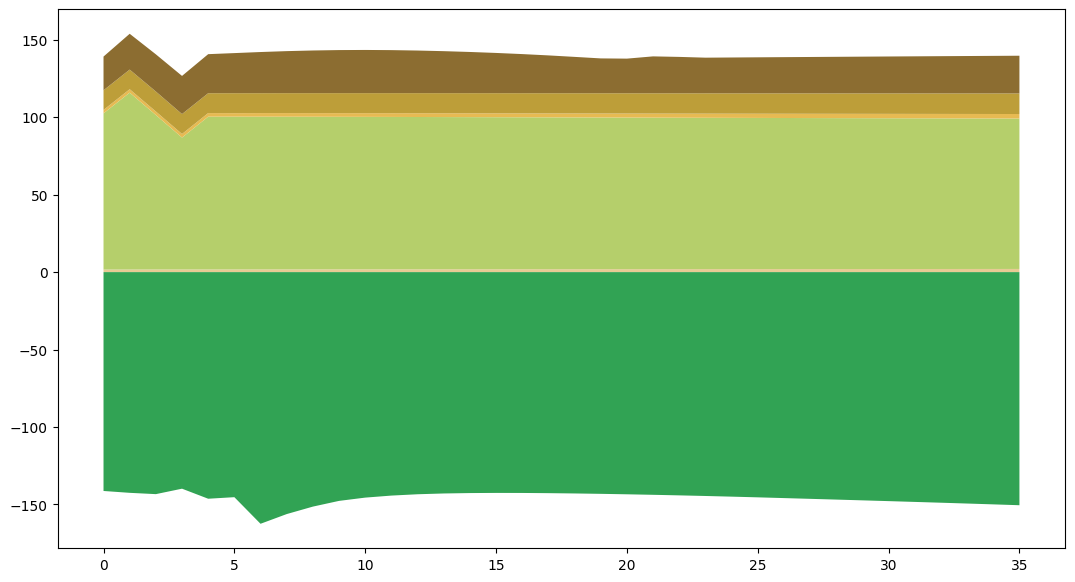

In [4]:
# Tutorial note: Run AFOLU sector model for validation and exploration. 
import sisepuede.models.afolu as mafl
model_afolu = mafl.AFOLU(matt, )
df_out = model_afolu(df_peru, )


# plot 
fig, ax = plt.subplots(figsize = (13, 7))
svp.plot_emissions_stack(
    df_out,
    matt,
    figtuple = (fig, ax), 
)

In [ ]:
# Tutorial note: Configure project directories, file paths, and SISepuede file structure. 
#df_peru.to_csv(path_data_built, encoding = "UTF-8", index = None, )




## 5. Working with generic transformations

The next cells explore and use the `transformation_general` helper to define
policy levers as transformations applied to the Peru input dataframe.


### What This Part Does

This section initializes the SISepuede machinery used to define and manage policy levers:

- Builds a **`transformations_peru`** directory on disk  
- Creates **Transformers**, **Transformations**, and **Strategies** objects  
- Prepares the system for **strategy-based scenario runs**  


### What a New User Needs to Know

- **`path_transformations`** is the directory where:
  - Strategy definitions  
  - Transformation specifications  
  - Helper files  
  are stored.

- This block constructs:
  - **`transformers`** → helper tools + input dataframe context  
  - **`transformations`** → complete set of transformation rules (policy levers)  
  - **`strategies`** → coherent collections of transformations representing scenarios  

- To use SISepuede for another country:
  - Change the **input dataframe**  
  - Optionally use a different transformations directory (e.g., `transformations_tza`)


## 6. Initializing Transformers, Transformations, and Strategies

The following cell(s) set up the Transformers / Transformations / Strategies
machinery used to define and manage policy levers for Peru. If you have already 
constructed the A6 experiments, you may not need to re-build experimental strategies.



### What a New User Needs to Know

- **Transformers**  
  Provide helper vectors and functions that allow transformations to apply smoothly across time, categories, and regions.

- **Transformations**  
  Represent *the rules* used to modify input data (e.g., scaling emissions, ramping fuel use, modifying forestry assumptions).

- **Strategies**  
  Bundle these transformations into a named scenario.  
  For Article 6, this could be:
  - A mitigation strategy  
  - A credit-selling country scenario  
  - An A6 cooperative implementation pathway  

- **This section is essential** if the goal is to run an Article 6 scenario, replicate past analyses, or generate new policy pathways.


### What Might Need Editing

If applying this workflow to another country or scenario:

- **`path_transformations`**  
  Should point to a country-specific directory (e.g., `transformations_chl`).

- **Input dataframe** (`df_peru`)  
  Should be swapped for the regional equivalent.

- **Strategy IDs and transformation specs**  
  May need to be updated depending on how many levers or policies your scenario requires.

This pattern, however, stays the same across all SISepuede regions and use cases.

In [9]:
# initialize a transformations set--will only run if the directory for transformations does not exist
# NOTE: you can always "start anew" with this


def get_transformations(
    path_transformations: pathlib.Path,
    df_inputs: pd.DataFrame,
) -> Tuple:
    """Using the path to transformations, build a transformations and strategies object.

    Returns a tuple of the form:

        (
            transformations,
            transformers,
            strategies
        )

        
    Function Arguments
    ------------------
    path_transformations : pathlib.Path
        Path to transformations directory usd to define transformations and strategies
    df_inputs : pd.DataFrame
        Base data DataFrame to modify with transformations
    """
    if not path_transformations.is_dir():
        print(f"Creating directory and instantiating default transformations at '{path_transformations}'...")

        transformers = trf.Transformers(
            {},
            df_input = df_inputs,
        )
        
        trf.instantiate_default_strategy_directory(
            transformers,
            path_transformations,
        )
    
    
    # read in the transformations and assign
    transformations = tmts.Transformations(
        path_transformations,
        df_input = df_inputs,
    )
    
    transformers = transformations.transformers
    
    # initialize a strategies objet
    strategies = stra.Strategies(
        transformations,
        export_path = "transformations",
        prebuild = True,
    )

    
    out = (
        transformers,
        transformations,
        strategies
    )

    return out



# run the function--we'll use this later, after we build the A6 strategies--to keep it cleaner
(
    transformers,
    transformations,
    strategies
) = get_transformations(
    path_transformations,
    df_peru,
)



## 7. Article 6 Transformations

### What This Section Is Doing

This block constructs the **set of transformations** used for an Article 6 (A6) scenario. 


#### **YOU ONLY NEED TO RUN THIS ONCE AFTER INITIALIZING THE BASIC STRATEGIES/TRANSFORMATIONS DIRECTORY**

This block will add rows to the strategy attribute table, which you do not want to do indefinitely. The rows that are added are dependent on the transformations/strategies that you want to evaluate.

We are *defining strategies that are used to conduct A6 analysis*

### Why This Matters for Article 6

Article 6 analysis requires:

- A **baseline** (e.g., business-as-usual or NDC)
- A **counterfactual scenario** modified by levers (representing Article 6 participation)

This block is where the machinery is built to define **those levers** in a modular, transparent way.

That makes this section a **core part of scenario construction**, unlike earlier diagnostics, which were mainly sanity checks.







## First, build some transformations
- We want to test, for example, what happens if we adjust the magnitude of rice CH4 reduction up or down.
- This block creates (and exports to the directory) transformations that will do that

In [38]:
# identify the transformation to stress
transformation_stress = "TX:AGRC:DEC_CH4_RICE_NDC2020_EST"
transformation = transformations.get_transformation(transformation_stress, )
transformer = transformers.get_transformer(transformation.transformer_code)

# this will be overwritten 
dict_transformation = transformation.config.dict_yaml

# update some info
key_cd = transformation.key_transformation_code
key_ds = transformation.key_description
key_id = transformation.key_identifiers
key_pa = transformation.key_parameters

# list of transformation codes that will be "swapped" below
_CODES_TO_EXCHANGE = []

# up the magnitude--NOTE: THIS IS NOT STRAIGHTFORWARD FOR ALL TRANSFORMERS; 
# SOME REQUIRE PATHWAYS (e.g., livestock manure management, wastewater treatment, etc.)
for lev in range(1, 10):
    i = lev*10
    
    # set some properties
    code = f"{transformation_stress}_P{i}"
    descrip = f"Implement {transformation_stress} at {i}%"
    fn_export = f"transformation_agrc_dec_ch4_rice_{i}_perc.yaml"

    _CODES_TO_EXCHANGE.append(code)
    
    # initialize the dictionary and update
    dict_export = deepcopy(dict_transformation)
    
    dict_export.update({key_ds: descrip, })
    dict_export[key_id].update({key_cd: code, })
    dict_export[key_pa].update({"magnitude": float(lev/10), })

    # write output
    path_config_out = transformations.dir_init.joinpath(fn_export)
    sf._write_yaml(dict_export, path_config_out, )

# update
(
    transformers,
    transformations,
    strategies
) = get_transformations(
    path_transformations,
    df_peru,
)

##  Now, for NDC and BASE, replace with Rice at 10% increments

In [64]:

# SPECIFY TRANSFORMATION CODES THAT ARE TO BE EVALUATED ON/OFF AGAINST A BASELINE (SEE strats_to_build BELOW)

transformations_build = [
    "TX:AGRC:DEC_CH4_RICE"
]

##  INITIALIZE KEY ELEMENTS

# some basic vars
delim = "|"
codes = []
descriptions = []
ids = []
names = []
specs = []

# set the new id number to start at
id_num = max(strategies.attribute_table.key_values) + 1

# initialize new strategies
_DF_ADDITIONAL_STRATEGIES = [strategies.attribute_table.table]

# set a prefix for A6 strategies
_PREFIX_PFLO = "PFLO:"
_PREFIX_PFLO_A6 = f"{_PREFIX_PFLO}A6_"

# reference strategy and associated specifications
dict_strat_builds = {
    #"PFLO:ALL": (1, 0), 
    "PFLO:NDC_2020": (1, 1),
}
dict_strat_pack = {}


#
strats_to_build = list(dict_strat_builds.keys())

for code in strats_to_build:
    # get transformaion information
    strat_ref = strategies.get_strategy(code, )
    all_transformations_ref = strat_ref.get_transformation_list(
        strat_ref.transformation_specification,
        transformations,
    )
    all_transformation_codes_ref = [x.code for x in all_transformations_ref]

    # add to dict
    tup = (strat_ref, all_transformations_ref, all_transformation_codes_ref, )
    dict_strat_pack.update({code: tup, })



# map transformer codes to all transformations
dict_transformer_code_to_transformations = transformations.get_transformation_codes_by_transformer_code()




##  ITERATE OVER TRANSFORMATIONS THAT NEED TO BE ADDED/REMOVED FROM BASE REF

for strat_build, strat_pack in dict_strat_pack.items():

    builds = dict_strat_builds.get(strat_build)
    (strat_ref, all_transformations_ref, all_transformation_codes_ref, ) = strat_pack

    
    for transformation_code in transformations_build:
    
        # check for transformations 
        transformation = transformations.get_transformation(transformation_code)
        if transformation is None:
            raise RuntimeError(f"Transformation code {transformation_code} not found.")
    
    
        # get transformer and check for existing transformation in reference strategy with that code
        all_transformations_with_code = dict_transformer_code_to_transformations.get(
            transformation.transformer_code, 
        )
    
        tfmns_with_trfr_in_strat_ref = set(all_transformations_with_code) & set(all_transformation_codes_ref)
        if len(tfmns_with_trfr_in_strat_ref) == 0: continue
    
        # transformation to replace with current one (for 100%) and remove (for 0%)
        transformation_remove = list(tfmns_with_trfr_in_strat_ref)[0]
    
        ## build transformation WITH x% implementation
        transformation_specification_0 = sorted([x for x in all_transformation_codes_ref if x != transformation_remove])
        transformation_specification_0_str = delim.join(transformation_specification_0)
        
        # now, replace with those identified above
        for code_new in _CODES_TO_EXCHANGE:
            transformation_specification_new = sorted(transformation_specification_0 + [code_new])
            transformation_specification_new_str = delim.join(transformation_specification_new)

            transformation_cur = transformations.get_transformation(code_new, )

            # 
            dict_info = transformation.config.dict_yaml
            name = dict_info[transformation.key_identifiers].get(transformation.key_transformation_name)
            name = f"A6 {strat_build} with {code_new}"

            code_new_strat = code_new.replace(f"{tmts._MODULE_CODE_SIGNATURE}:", "", )
            code_new_strat = f"A6:{code_new_strat}"
            
            # append
            codes.append(code_new_strat)
            descriptions.append(f"{name} for A6")
            ids.append(id_num)
            names.append(name)
            specs.append(transformation_specification_new_str)

            id_num += 1


# build as data frame and append
df_a6 = pd.DataFrame(
    {
        strategies.attribute_table.key: ids,
        strategies.field_baseline_strategy: np.zeros(len(specs)).astype(int),
        strategies.field_description: descriptions,
        strategies.field_strategy_code: codes,
        strategies.field_strategy_name: names,
        strategies.field_transformation_specification: specs,
    }
)
_DF_ADDITIONAL_STRATEGIES.append(df_a6, )


## Similarly to the cell above, this next cell only needs to be run once (per transformations package)

This cell generates **Whirlpool** and **Tornado** runs.

### Tornado

- Use a strategy (e.g. NDC) as a set Transformations
- Turn on each Transformation in the set one-by-one against the baseline scenario

### Whirlpool 

- Start with a strategy of interest, such as NDC
- **Remove** individual transformations one-by-one from the strategy


In [66]:
_STRATEGY_STRESS = 6003
field_strat_id = strategies.attribute_table.key

# Build tornado and append to new df list
df_tornado = strategies.build_tornado_strategies(
    0,
    strategy_stress = _STRATEGY_STRESS,
    ids = int(df_a6[field_strat_id].max() + 1),
)
_DF_ADDITIONAL_STRATEGIES.append(df_tornado, )

# Build whirlpool and append to new df list
df_whirlpool = strategies.build_whirlpool_strategies(
    _STRATEGY_STRESS,
    ids = df_tornado[field_strat_id].max() + 1,
)
_DF_ADDITIONAL_STRATEGIES.append(df_whirlpool, );
    
attr_strat_out = pd.concat(_DF_ADDITIONAL_STRATEGIES, )

## IMPORTANT! Export the new strategy attributes file

- This will export a new strategy attributes file
- Careful doing this--it shouldn't harm any strategies you've built otherwise, but it's always good to make a backup (hello GitHub!) before you export in case there are issues
- after exporting, we'll have to reload the transformations object

In [70]:

sf._write_csv(
    attr_strat_out,
    strategies.path_strategy_definition,
)



True

# Now, reinstantiate strategies and transformations to reflect the experimental strategies we just built

In [71]:
# run the function--we'll use this later, after we build the A6 strategies--to keep it cleaner
(
    transformers,
    transformations,
    strategies
) = get_transformations(
    path_transformations,
    df_peru,
)




## Now, set the strategies we want to run for our experiment

### Select the strategies that we need to run

- This is an example that focuses on (a) varying rice up and down and (b) the A6 on/off runs defined above
- If you are evaluating the performance of another individual transformation, you'll need to change `AGRC:DEC_CH4_RICE` to identify other strategies

###  setup ids that we want to build
- We will define the strategies that are associated with the A6 analysis
  `strat_ids_a6` is a list of these strategy ids to run in the experiment

###  build to template
- Note: we cannot use a `SISEPUEDE` object successfully to run the strategies unless we rebuild the templates using `strategies.build_strategies_to_templates`

In [82]:
tab = strategies.attribute_table.table

# demonstrate A6 runs
strats_run = ["BASE", "PFLO:ALL", "PFLO:NDC_2020"]
strats_run += [
    x for x in list(tab[strategies.field_strategy_code]) 
    if False 
    or x.startswith("A6")
    or x.startswith("TORNADO")
    or x.startswith("WHIRLPOOL")
]

strat_ids_run = [strategies.get_strategy_id(x) for x in strats_run]

# build templates--trajectory groups are not important right now
strategies.build_strategies_to_templates(
    include_simplex_group_as_trajgroup = False,
    strategies = strat_ids_run,
)


0

# Next, build a SISEPUEDE object and load strategies
- This is what we'll use to actually run the analysis

In [83]:
import sisepuede as si

ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    initialize_as_dummy = False,
    regions = [_REGION_NAME],
    strategies = strategies,
)





2026-03-07 23:04:07,634 - INFO - Successfully initialized SISEPUEDEFileStructure.
2026-03-07 23:04:07,635 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2026-03-07 23:04:07,636 - INFO - 	Setting export engine to 'csv'.
2026-03-07 23:04:07,636 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2026-03-07 23:04:07,636 - INFO - Successfully instantiated table ANALYSIS_METADATA
2026-03-07 23:04:07,637 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2026-03-07 23:04:07,637 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2026-03-07 23:04:07,637 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2026-03-07 23:04:07,638 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2026-03-07 23:04:07,638 - WARNING - No index fi

[juliapkg] Found dependencies: /Users/usuario/git/sisepuede/sisepuede/julia/pyjuliapkg/juliapkg.json
[juliapkg] Found dependencies: /opt/miniconda3/envs/sisepuede/lib/python3.11/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /opt/miniconda3/envs/sisepuede/lib/python3.11/site-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia =1.11.5, =1.11.6
[juliapkg] Using Julia 1.11.6 at /Users/usuario/.julia/juliaup/julia-1.11.6+0.aarch64.apple.darwin14/bin/julia
[juliapkg] Using Julia project at /Users/usuario/git/sisepuede/sisepuede/julia
[juliapkg] Writing Project.toml:
             [deps]
             Cbc = "9961bab8-2fa3-5c5a-9d89-47fab24efd76"
             Clp = "e2554f3b-3117-50c0-817c-e040a3ddf72d"
             DataFrames = "a93c6f00-e57d-5684-b7b6-d8193f3e46c0"
             GLPK = "60bf3e95-4087-53dc-ae20-288a0d20c6a6"
             HiGHS = "87dc4568-4c63-4d18-b0c0-bb2238e4078b"
             Ipopt = "b6b21f68-93f8-5de0-b562-5493be1d77c9"
             JuMP = "407

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Hwloc_jll ────────── v2.13.0+0
   Installed dlfcn_win32_jll ──── v1.4.2+0
   Installed MicroMamba ───────── v0.1.15
   Installed SpecialFunctions ─── v2.7.1
   Installed JSON ─────────────── v1.4.0
   Installed Preferences ──────── v1.5.2
   Installed SQLite ───────────── v1.8.0
   Installed PrettyTables ─────── v3.2.3
   Installed SentinelArrays ───── v1.4.9
   Installed micromamba_jll ───── v2.3.1+0
   Installed ForwardDiff ──────── v1.3.2
   Installed SQLite_jll ───────── v3.51.2+0
   Installed OpenBLAS32_jll ───── v0.3.30+0
   Installed MathOptIIS ───────── v0.1.2
   Installed Ipopt ────────────── v1.14.1
   Installed HiGHS_jll ────────── v1.13.1+0
   Installed HiGHS ────────────── v1.22.0
   Installed CondaPkg ─────────── v0.2.34
   Installed JuMP ─────────────── v1.30.0
   Installed StructUtils ──────── v2.6.3
   Installed StringManipulation ─ v0.4.4
   Installed MathOptInter

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1361.1 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2026-03-07 23:05:59,438 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2026-03-07 23:05:59,452 - INFO - Successfully initialized SISEPUEDEModels.
2026-03-07 23:05:59,457 - INFO - Table ANALYSIS_METADATA successfully written to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_ru

## 8. Running example strategies via a scenario manager (optional)

These cells illustrate how to use a higher-level scenario manager (`ssp`) to
run predefined strategies such as `strat_base()` and `strat_a6()`. They are
useful examples but not strictly required to construct the core Peru inputs.

### What a New User Needs to Know

**`SISEPUEDEModels`** is the top-level **model runner** in SISepuede:

- It **orchestrates all sector models** (energy, AFOLU, industry, transport, waste, etc.).  
- It uses:
  - **Model metadata** (`matt`)  
  - **Reference files** from Julia and NemoMod (via `file_struct`)  

### For Strategy Runs

To run **scenario-based** (rather than baseline) simulations:

- Replace **`df_peru`** with a **transformed input dataframe** created using one or more policy levers or a defined strategy.
- Alternatively, use the **scenario manager approach** shown earlier, such as:
  - `strat_base()`
  - `strat_a6()`

This process allows you to generate, compare, and analyze **multiple scenarios** that all originate from the same base input dataset.



In [84]:

dict_run = {
    ssp.key_future: [0],
    ssp.key_design: [0],
    ssp.key_strategy: strat_ids_run,
}

# we'll save inputs since we're doing a small set of runs 
dict_successful = ssp(
    dict_run, 
    force_overwrite_existing_primary_keys = True,
    save_inputs = True,
)

2026-03-07 23:06:02,146 - INFO - 
***	STARTING REGION peru	***

2026-03-07 23:06:03,681 - INFO - Trying run primary_id = 0 in region peru
2026-03-07 23:06:03,681 - INFO - Running AFOLU model
2026-03-07 23:06:03,897 - INFO - AFOLU model run successfully completed
2026-03-07 23:06:03,897 - INFO - Running CircularEconomy model
2026-03-07 23:06:03,920 - INFO - CircularEconomy model run successfully completed
2026-03-07 23:06:03,921 - INFO - Running IPPU model
2026-03-07 23:06:03,959 - INFO - IPPU model run successfully completed
2026-03-07 23:06:03,959 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-07 23:06:03,969 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-07 23:06:04,013 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-07 23:06:04,013 - INFO - Running Energy model (Electricity and Fuel Production: trying to ca

2026-07-Mar 23:06:04.419 Opened SQLite database at /Users/usuario/git/sisepuede/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-07-Mar 23:06:04.433 Added NEMO structure to SQLite database at /Users/usuario/git/sisepuede/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-07-Mar 23:06:19.502 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-07-Mar 23:06:20.003 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-07-Mar 23:06:39.730 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-07-Mar 23:06:39.778 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].


2026-03-07 23:07:31,351 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-07 23:07:31,358 - INFO - EnergyProduction model run successfully completed
2026-03-07 23:07:31,358 - INFO - Running Energy (Fugitive Emissions)
2026-03-07 23:07:31,377 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-07 23:07:31,378 - INFO - Appending Socioeconomic outputs
2026-03-07 23:07:31,382 - INFO - Socioeconomic outputs successfully appended.
2026-03-07 23:07:31,384 - INFO - Model run for primary_id = 0 successfully completed in 87.7 seconds (n_tries = 1).
2026-03-07 23:07:31,403 - INFO - Trying run primary_id = 87087 in region peru
2026-03-07 23:07:31,404 - INFO - Running AFOLU model


2026-07-Mar 23:07:31.235 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-07 23:07:31,612 - INFO - AFOLU model run successfully completed
2026-03-07 23:07:31,613 - INFO - Running CircularEconomy model
2026-03-07 23:07:31,634 - INFO - CircularEconomy model run successfully completed
2026-03-07 23:07:31,635 - INFO - Running IPPU model
2026-03-07 23:07:31,671 - INFO - IPPU model run successfully completed
2026-03-07 23:07:31,671 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-07 23:07:31,680 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-07 23:07:31,724 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-07 23:07:31,724 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


...

2026-03-08 06:01:16,207 - INFO - AFOLU model run successfully completed
2026-03-08 06:01:16,207 - INFO - Running CircularEconomy model
2026-03-08 06:01:16,228 - INFO - CircularEconomy model run successfully completed
2026-03-08 06:01:16,228 - INFO - Running IPPU model
2026-03-08 06:01:16,265 - INFO - IPPU model run successfully completed
2026-03-08 06:01:16,265 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-08 06:01:16,274 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-08 06:01:16,316 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-08 06:01:16,316 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


2026-08-Mar 06:01:16.897 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-08-Mar 06:01:16.943 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].


2026-03-08 06:02:14,253 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-08 06:02:14,259 - INFO - EnergyProduction model run successfully completed
2026-03-08 06:02:14,259 - INFO - Running Energy (Fugitive Emissions)
2026-03-08 06:02:14,277 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-08 06:02:14,277 - INFO - Appending Socioeconomic outputs
2026-03-08 06:02:14,281 - INFO - Socioeconomic outputs successfully appended.
2026-03-08 06:02:14,282 - INFO - Model run for primary_id = 207207 successfully completed in 58.28 seconds (n_tries = 1).
2026-03-08 06:02:14,284 - INFO - 
***	 REGION peru COMPLETE	***

2026-03-08 06:02:14,367 - INFO - Table MODEL_OUTPUT successfully appended to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2026-03-07T23;04;07.022202/sisepuede_run_2026-03-07T23;04;07.022202_output_database/MODEL_OUTPUT.csv.
2026-03-08 06:02:14,369 - INFO - Table ATTRIBUTE_PRIMARY successfully written to /Users/usua

2026-08-Mar 06:01:33.423 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-08-Mar 06:01:33.457 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-08-Mar 06:02:14.171 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-08 06:02:14,484 - INFO - Table MODEL_INPUT successfully appended to /Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2026-03-07T23;04;07.022202/sisepuede_run_2026-03-07T23;04;07.022202_output_database/MODEL_INPUT.csv.


In [85]:
# check primaries that ran
primaries = dict_successful.get("peru")


In [86]:
##  check the primaries that ran in table for
attribute_prim = ssp.odpt_primary.get_indexing_dataframe_from_primary_key(primaries)

###  The next block allows you to read in the inputs, outputs, and generate a summary set of files for use in Tableau  other visualization software

In [87]:
df_out_tmp = ssp.read_output(None)
df_in_tmp = ssp.read_input(None)
ssp.generate_summary_files(None, export = True, );

## 9. You can visualize outputs in stakcs
- Explore the output data in `df_out` or inputs in `df_in`
- `svp.plot_emissions_stack` will automatically plot subsector total emissions contained in the output dataframe
- May want to set `id_primary` to only plot a single primary id

In [ ]:
id_primary_plot = 0       # set a primary id to plot
fig, ax = plt.subplots(figsize = (11, 7))
svp.plot_emissions_stack(
    df_out[
        df_out[ssp.key_primary].isin([id_primary_plot])
    ],
    matt,
    figtuple = (fig, ax),
)
ax.legend()


### You can also plot individual variables

In [ ]:
# Tutorial note: Exploratory inspection, printing, or plotting for validation. 
modvar = matt.get_variable("Land Use Area", )
fig, ax = plt.subplots(figsize = (12, 8))
df_run_enerprod[modvar.fields].plot.area(cmap = "tab20", ax = ax, )
ax.legend(loc = "upper right")
